# Демонстрации к лекции 3: двойственность руками и кодом

Ноутбук читается сверху вниз. Разминка и четыре части:

- **(0)** три задачки из повторения в начале лекции (раздел 1 конспекта): три «середины» одних данных, спасатель на пляже, самый большой круг в многоугольнике — все три решаются тем, что было в лекциях 1–2, а последняя оставляет крючок к двойственности;
- **(a)** одномерный пример лекции ($\min x^2$ при ограничении): функция Лагранжа, двойственная функция $d(\mu)$ в коде, слабая и сильная двойственность на числах;
- **(b)** двойственность QP на ящике из демо к лекции 2: максимизируем $d(\mu)$ численно, сверяем с уже известным решением, комплементарная нежёсткость, и тот же множитель из баланса сил $\nabla f(x^\ast)=\mu\nabla h(x^\ast)$;
- **(c)** двойственность LP на двух старых знакомых — планировании производства (лекция 1) и диете (ДЗ 1): `res.ineqlin.marginals` против явного решения двойственной задачи и против разложения градиента прибыли по нормалям активных ограничений;
- **(d)** когда двойственности нельзя доверять — неделимый завод (конечный зазор), невыпуклый пример с бесконечным зазором и «скрытая выпуклость» задачи из ДЗ 2.

Конспект: [`lecture03.md`](lecture03.md). Запуск: `uv run jupyter lab` в корне репозитория.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

BLUE, ORANGE, AQUA, RED, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})
rng = np.random.default_rng(3)

## (0) Разминка: три задачки из повторения

Раздел 1 конспекта. Ничего нового — только то, что было в лекциях 1–2: класс задачи, вспомогательные переменные, выпуклость, условие оптимальности. Каждую задачу решаем солвером и сверяем с ответом «руками».

**Задача А. Три «середины».** Для данных $a=(1,2,3,4,20)$ минимизируем $\sum(x-a_i)^2$, $\sum|x-a_i|$ и $\max_i|x-a_i|$. Первая — QP без ограничений ($f'=0$ даёт среднее), две другие негладкие, но со вспомогательными $s_i\ge\pm(x-a_i)$ становятся LP.

In [2]:
a = np.array([1.0, 2.0, 3.0, 4.0, 20.0])
n = len(a)

# (ii) min sum s_i  при  -s_i <= x - a_i <= s_i ; переменные (x, s_1..s_n)
rows, rhs = [], []
for i in range(n):
    r1 = np.zeros(n + 1); r1[0], r1[1 + i] = 1, -1;  rows.append(r1); rhs.append(a[i])    #  x - s_i <= a_i
    r2 = np.zeros(n + 1); r2[0], r2[1 + i] = -1, -1; rows.append(r2); rhs.append(-a[i])   # -x - s_i <= -a_i
lad = linprog(np.r_[0, np.ones(n)], A_ub=np.array(rows), b_ub=rhs, bounds=[(None, None)] + [(0, None)] * n)

# (iii) min s  при  -s <= x - a_i <= s ; переменные (x, s)
rows = [[1, -1] if k % 2 == 0 else [-1, -1] for k in range(2 * n)]
rhs = [v for ai in a for v in (ai, -ai)]
mm = linprog([0, 1], A_ub=np.array(rows, float), b_ub=rhs, bounds=[(None, None), (0, None)])

print("сумма квадратов -> среднее:          ", a.mean())
print("сумма модулей   -> LP:", lad.x[0].round(6), " np.median:", np.median(a))
print("максимум модуля -> LP:", mm.x[0].round(6), "  середина размаха:", (a.min() + a.max()) / 2)

сумма квадратов -> среднее:           6.0
сумма модулей   -> LP: 3.0  np.median: 3.0
максимум модуля -> LP: 10.5   середина размаха: 10.5


Три разные «середины» одних данных; выброс $20$ тянет среднее и минимакс, медиане он безразличен. Все три задачи выпуклы — найденное является глобальным минимумом.

**Задача Б. Спасатель на пляже.** $T(x)=\sqrt{30^2+x^2}/5+\sqrt{20^2+(40-x)^2}/1.5$ — строго выпукла и коэрцитивна, решение существует и единственно; в нём $T'(x^\ast)=0$, что после упрощения — закон Снеллиуса $\sin\theta_1/v_1=\sin\theta_2/v_2$. Формулы для $x^\ast$ нет (уравнение четвёртой степени), число даёт солвер.

x* = 35.303 м,  T* = 22.962 с
закон Снеллиуса: sin1/v1 = 0.152405,  sin2/v2 = 0.152405
для сравнения: по прямой 24.759 с, до траверза и поперёк 23.333 с


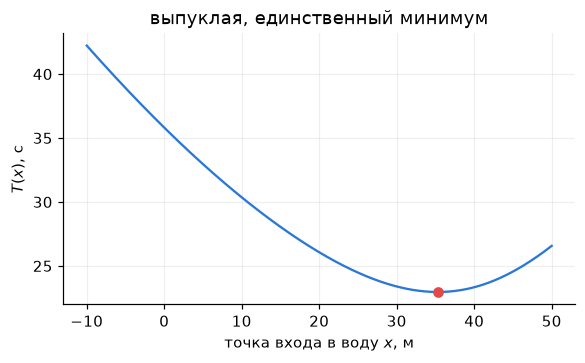

In [3]:
from scipy.optimize import minimize_scalar

a_s, b_w, d, v1, v2 = 30.0, 20.0, 40.0, 5.0, 1.5
T = lambda x: np.sqrt(a_s**2 + x**2) / v1 + np.sqrt(b_w**2 + (d - x)**2) / v2

res = minimize_scalar(T, bounds=(0, d), method="bounded", options=dict(xatol=1e-10))
xs = res.x
sin1, sin2 = xs / np.sqrt(a_s**2 + xs**2), (d - xs) / np.sqrt(b_w**2 + (d - xs)**2)
print(f"x* = {xs:.3f} м,  T* = {res.fun:.3f} с")
print(f"закон Снеллиуса: sin1/v1 = {sin1 / v1:.6f},  sin2/v2 = {sin2 / v2:.6f}")
print(f"для сравнения: по прямой {T(d * a_s / (a_s + b_w)):.3f} с, до траверза и поперёк {T(d):.3f} с")

x = np.linspace(-10, 50, 400)
plt.figure(figsize=(6, 3.2))
plt.plot(x, T(x), color=BLUE); plt.plot(xs, res.fun, "o", color=RED)
plt.xlabel("точка входа в воду $x$, м"); plt.ylabel("$T(x)$, с"); plt.title("выпуклая, единственный минимум")
plt.show()

**Задача В. Самый большой круг в многоугольнике** $\{a_i^\top x\le b_i\}$. Круг $(c,r)$ лежит в полуплоскости $i$ тогда и только тогда, когда $a_i^\top c+r\lVert a_i\rVert\le b_i$ — линейно по $(c,r)$, значит вся задача — LP по трём переменным. Вместе с решением `linprog` возвращает `res.ineqlin.marginals` — по числу на ограничение. Запомните эти числа: к ним вернёмся в части (c), когда узнаем, что это такое.

In [4]:
A = np.array([[-1.0, 0.0], [0.0, -1.0], [1.0, 2.0], [3.0, 1.0], [1.0, -1.0]])   # a_i^T x <= b_i
b = np.array([0.0, 0.0, 8.0, 12.0, 3.0])
norms = np.linalg.norm(A, axis=1)

res = linprog([0, 0, -1], A_ub=np.c_[A, norms], b_ub=b, bounds=[(None, None), (None, None), (0, None)])
c_, r_ = res.x[:2], res.x[2]
mu = -res.ineqlin.marginals          # знак: linprog минимизирует -r, см. часть (c)
print("центр c* =", c_.round(4), " радиус r* =", r_.round(4), " (6 - 2*sqrt(5) =", (6 - 2 * np.sqrt(5)).round(4), ")")
print("зазор по ограничениям b - A c - r|a|:", res.slack.round(4), " -> активны", np.where(res.slack < 1e-9)[0] + 1)
print("marginals:", mu.round(4))
print("сумма mu_i a_i =", (mu @ A).round(6), "   сумма mu_i |a_i| =", (mu @ norms).round(6))

центр c* = [1.5279 1.5279]  радиус r* = 1.5279  (6 - 2*sqrt(5) = 1.5279 )
зазор по ограничениям b - A c - r|a|: [0.     0.     0.     1.057  0.8393]  -> активны [1 2 3]
marginals: [0.191 0.382 0.191 0.    0.   ]
сумма mu_i a_i = [0. 0.]    сумма mu_i |a_i| = 1.0


Круг касается трёх сторон (1, 2, 3) — они активны, у них множители положительны; у сторон 4 и 5 зазор положителен и множители **нулевые**. Это комплементарная нежёсткость (раздел 7 конспекта) в чистом виде; а равенства $\sum_i\mu_i a_i=0$ и $\sum_i\mu_i\lVert a_i\rVert=1$ — условие стационарности Лагранжиана по $(c,r)$, до которого мы дойдём в лекции 10. Пока — просто наблюдение: «круг держат те стороны, которых он касается».

## (a) Одномерная задача: $\min x^2$ при $x \geq 3$... то есть $\min (x-2)^2$ при $x \geq 3$

Задача из раздела 4 конспекта. Напишем $L(x,\mu) = (x-2)^2 - \mu(x-3)$ и $d(\mu) = \inf_x L(x,\mu)$ буквально как функции, без бумаги и ручки — минимум по $x$ при фиксированном $\mu$ найдём `scipy.optimize.minimize_scalar`-эквивалентом (здесь проще — просто перебором на мелкой сетке, чтобы не считать производную руками ещё раз).

In [5]:
f = lambda x: (x - 2) ** 2
h = lambda x: x - 3            # ограничение h(x) >= 0

def L(x, mu):
    return f(x) - mu * h(x)

def d(mu, grid=np.linspace(-20, 20, 200_001)):
    return L(grid, mu).min()

mus = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 4])
dvals = np.array([d(mu) for mu in mus])
pstar = f(3.0)
print(" mu   d(mu)   d(mu) <= p*?")
for mu, dv in zip(mus, dvals):
    print(f"{mu:4.1f}  {dv:6.3f}   {dv <= pstar + 1e-9}")
print("\np* =", pstar)
mu_star = mus[np.argmax(dvals)]
print("грубый максимум по перебору достигается при mu =", mu_star, ", d =", dvals.max())

 mu   d(mu)   d(mu) <= p*?
 0.0   0.000   True
 0.5   0.438   True
 1.0   0.750   True
 1.5   0.938   True
 2.0   1.000   True
 2.5   0.938   True
 3.0   0.750   True
 4.0   0.000   True

p* = 1.0
грубый максимум по перебору достигается при mu = 2.0 , d = 1.0


Всё сходится: каждое найденное $d(\mu) \le p^\ast = 1$ (слабая двойственность, раздел 3), а при $\mu=2$ — равенство. Теперь то же самое по формуле $d(\mu) = -\mu^2/4+\mu$, выведенной в разделе 4, и картинки: семейство $L(x,\mu)$ (рис. 02 конспекта) и сама $d(\mu)$ (рис. 04).

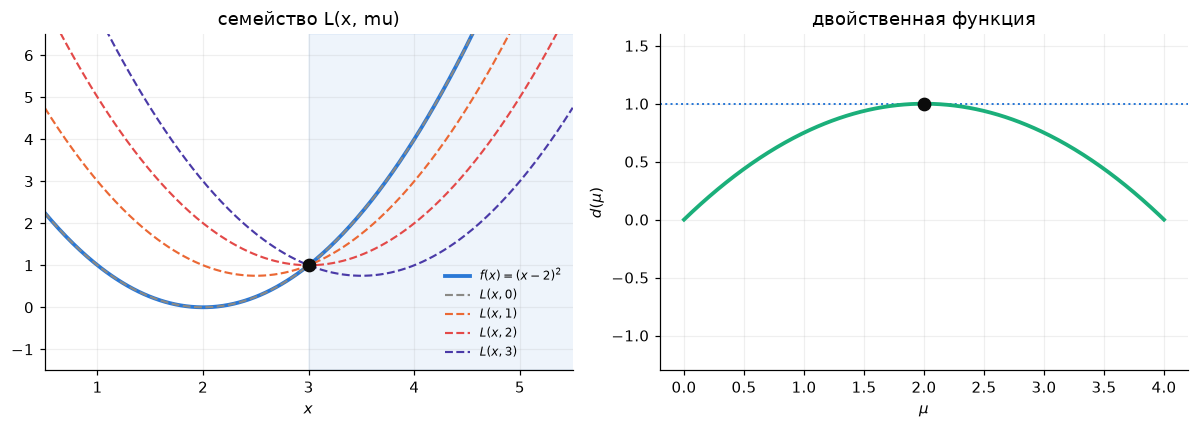

mu* = 2.0  d* = 0.9999999999999998  p* = 1.0


In [6]:
d_formula = lambda mu: -mu**2 / 4 + mu
mu_grid = np.linspace(0, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.linspace(0.5, 5.5, 300)
axes[0].axvspan(3, 5.6, color=BLUE, alpha=0.08)
axes[0].plot(x, f(x), color=BLUE, lw=2.5, label="$f(x)=(x-2)^2$")
for mu, col in zip((0, 1, 2, 3), (GRAY, ORANGE, RED, "#4a3aa7")):
    axes[0].plot(x, L(x, mu), color=col, ls="--", lw=1.4, label=f"$L(x,{mu})$")
axes[0].plot(3, 1, "o", color=INK, ms=8)
axes[0].set(xlim=(0.5, 5.5), ylim=(-1.5, 6.5), xlabel="$x$", title="семейство L(x, mu)")
axes[0].legend(fontsize=8)

axes[1].axhline(pstar, color=BLUE, ls=":", lw=1.3)
axes[1].plot(mu_grid, d_formula(mu_grid), color=AQUA, lw=2.5)
axes[1].plot(2, 1, "o", color=INK, ms=8)
axes[1].set(xlabel="$\\mu$", ylabel="$d(\\mu)$", title="двойственная функция", ylim=(-1.3, 1.6))
plt.tight_layout(); plt.show()

# максимум d(mu) честно через minimize (на -d, с ограничением mu >= 0)
res = minimize(lambda mu: -d_formula(mu[0]), x0=[0.0], bounds=[(0, None)])
print("mu* =", res.x[0].round(6), " d* =", -res.fun, " p* =", pstar)

## (b) Двойственность QP: ящик из лекции 2

Тот же $f(x)=\tfrac12 x^\top Qx+c^\top x$, $Q=\begin{pmatrix}2&0.5\\0.5&1\end{pmatrix}$, $c=(-3,-1)$, на $[-1,1]^2$, что и в демо к лекции 2, часть (c). Известное решение: $x^\ast=(1,\,0.5)$, $f^\ast=-2.125$, активна только грань $x_1=1$. Двойственная функция для $h=(1-x_1,\,1+x_1,\,1-x_2,\,1+x_2)\ge 0$ (раздел 9 конспекта) считается в закрытом виде через $Q^{-1}$ — никакой отдельной минимизации по $x$ не нужно.

x* = [1.  0.5]  f* = -2.125


максимум d(mu) по 20000 случайным mu >= 0: -3.1234  (должно быть <= f* = -2.125 )
mu* = [0.75 0.   0.   0.  ]
d* = -2.125  f* = -2.125  (сильная двойственность: совпадают)
x, восстановленный из mu*: [1.  0.5]  (совпадает с x* — тоже следствие KKT)


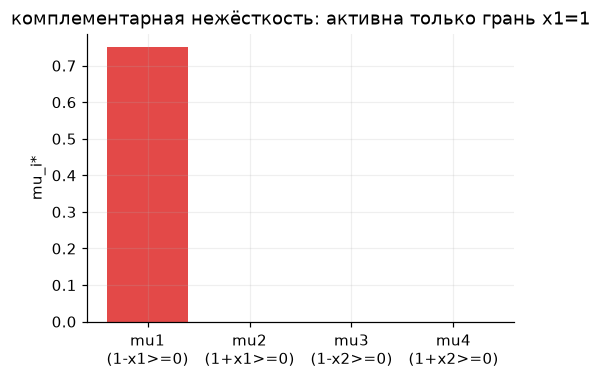

In [7]:
Q = np.array([[2.0, 0.5], [0.5, 1.0]])
c = np.array([-3.0, -1.0])
Qinv = np.linalg.inv(Q)

fqp = lambda x: 0.5 * x @ Q @ x + c @ x
xstar = minimize(fqp, x0=np.zeros(2), jac=lambda x: Q @ x + c, method="L-BFGS-B",
                  bounds=[(-1, 1), (-1, 1)]).x
print("x* =", xstar.round(4), " f* =", fqp(xstar).round(6))

def dual_d(mu):
    mu = np.asarray(mu, float)
    shift = np.array([mu[0] - mu[1], mu[2] - mu[3]])      # коэффициент при x в L(x,mu)
    xun = -Qinv @ (c + shift)
    return 0.5 * xun @ Q @ xun + (c + shift) @ xun - mu.sum(), xun

# слабая двойственность на случайных mu >= 0
worst = max(dual_d(rng.uniform(0, 5, 4))[0] for _ in range(20_000))
print("максимум d(mu) по 20000 случайным mu >= 0:", round(worst, 4), " (должно быть <= f* =", round(fqp(xstar), 4), ")")

# максимизация d(mu) по mu >= 0
res = minimize(lambda mu: -dual_d(np.clip(mu, 0, None))[0], x0=np.ones(4), method="Nelder-Mead",
               options={"xatol": 1e-10, "fatol": 1e-12, "maxiter": 20_000})
mu_star = np.clip(res.x, 0, None)
dstar, x_from_dual = dual_d(mu_star)
print("mu* =", mu_star.round(4))
print("d* =", round(dstar, 6), " f* =", round(fqp(xstar), 6), " (сильная двойственность: совпадают)")
print("x, восстановленный из mu*:", x_from_dual.round(4), " (совпадает с x* — тоже следствие KKT)")

fig, ax = plt.subplots(figsize=(5, 3.4))
names = ["mu1\n(1-x1>=0)", "mu2\n(1+x1>=0)", "mu3\n(1-x2>=0)", "mu4\n(1+x2>=0)"]
ax.bar(names, mu_star, color=[RED if m > 1e-6 else GRAY for m in mu_star])
ax.set(ylabel="mu_i*", title="комплементарная нежёсткость: активна только грань x1=1")
plt.show()

**Тот же множитель из баланса сил** (раздел 5.1 конспекта). Двойственную задачу можно вообще не решать: в решении градиент цели должен быть уравновешен реакцией активных стенок, $
abla f(x^st)=\sum_i\mu_i
abla h_i(x^st)$, $\mu\ge0$. Активна одна грань $x_1\le1$, то есть $h_1=1-x_1$, $
abla h_1=(-1,0)$ — значит $\mu_1$ читается прямо из первой координаты $
abla f(x^st)$.

In [8]:
grad_f = Q @ xstar + c
grad_h = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]], float)     # нормали граней h = (1-x1, 1+x1, 1-x2, 1+x2)
active = np.isclose([1 - xstar[0], 1 + xstar[0], 1 - xstar[1], 1 + xstar[1]], 0)
print("grad f(x*) =", grad_f.round(4), " активные грани:", np.where(active)[0] + 1)
mu_force = np.linalg.lstsq(grad_h[active].T, grad_f, rcond=None)[0]
print("mu из баланса сил (по активным граням):", mu_force.round(4))
print("mu* из максимизации d(mu):              ", mu_star[active].round(4), " -> одно и то же число")
print("проверка: sum mu_i grad h_i =", (mu_star @ grad_h).round(4), " = grad f")

grad f(x*) = [-0.75  0.  ]  активные грани: [1]
mu из баланса сил (по активным граням): [0.75]
mu* из максимизации d(mu):               [0.75]  -> одно и то же число
проверка: sum mu_i grad h_i = [-0.75  0.  ]  = grad f


## (c) Двойственность LP: планирование производства и диета

Для LP `scipy.optimize.linprog` уже отдаёт двойственные переменные в `res.ineqlin.marginals` — решать двойственную задачу отдельно нужно только чтобы *проверить* это (или когда солвер их не даёт). Начнём с планирования производства (лекция 1, §7.2): $\max\,3x_1+5x_2$ при $x_1\le4$, $2x_2\le12$, $3x_1+2x_2\le18$, $x\ge0$.

In [9]:
A = np.array([[1.0, 0.0], [0.0, 2.0], [3.0, 2.0]])
b = np.array([4.0, 12.0, 18.0])
c_profit = np.array([3.0, 5.0])

res_p = linprog(-c_profit, A_ub=A, b_ub=b, bounds=[(0, None)] * 2, method="highs")
y_from_marginals = -res_p.ineqlin.marginals
print("x* =", res_p.x.round(4), " прибыль =", round(-res_p.fun, 4))
print("y* (из marginals) =", y_from_marginals.round(4))

# двойственная LP явно: min b^T y при A^T y >= c, y >= 0
res_d = linprog(b, A_ub=-A.T, b_ub=-c_profit, bounds=[(0, None)] * 3, method="highs")
print("y* (явное решение двойственной) =", res_d.x.round(4), " значение =", round(res_d.fun, 4))
print("совпадает с прибылью:", np.isclose(res_d.fun, -res_p.fun))

# комплементарная нежёсткость
slack = b - A @ res_p.x
print("\nневязки b - Ax* :", slack.round(4), " (0 -> активно)")
print("y* * невязка     :", (y_from_marginals * slack).round(6), " (должно быть ~0 для каждой пары)")

x* = [2. 6.]  прибыль = 36.0
y* (из marginals) = [0.  1.5 1. ]
y* (явное решение двойственной) = [0.  1.5 1. ]  значение = 36.0
совпадает с прибылью: True

невязки b - Ax* : [2. 0. 0.]  (0 -> активно)
y* * невязка     : [0. 0. 0.]  (должно быть ~0 для каждой пары)


**Теневые цены — это коэффициенты разложения градиента** (раздел 5.1, панель (в)). В вершине $(2,6)$ активны ограничения 2 и 3; их внешние нормали — строки $a_2=(0,2)$ и $a_3=(3,2)$ матрицы $A$. Разложим градиент прибыли $c=(3,5)$ по этим двум векторам — получится $y_2^st, y_3^st$, а у неактивного ограничения 1 вес нулевой.

In [10]:
active = np.isclose(slack, 0)
y_active = np.linalg.solve(A[active].T, c_profit)          # c = sum_i y_i a_i по активным i
y_from_gradient = np.zeros(3); y_from_gradient[active] = y_active
print("активные ограничения:", np.where(active)[0] + 1)
print("y* из разложения градиента:", y_from_gradient.round(4))
print("y* из marginals:           ", y_from_marginals.round(4), " -> совпадают")
print("проверка: c = A^T y =", (A.T @ y_from_gradient).round(4))

активные ограничения: [2 3]
y* из разложения градиента: [0.  1.5 1. ]
y* из marginals:            [0.  1.5 1. ]  -> совпадают
проверка: c = A^T y = [3. 5.]


Теперь диета из ДЗ 1: $\min c^\top x$ при $Ax\ge b$, $x\ge0$, $c=(2,3,1.5,4)$, $b=(12,8,6)$. Двойственная — $\max b^\top y$ при $A^\top y\le c$, $y\ge0$; в `linprog` это `A_ub=-A_diet` для примальной, и знак меняется соответственно.

In [11]:
c_diet = np.array([2.0, 3.0, 1.5, 4.0])
A_diet = np.array([[1.0, 2.0, 0.0, 3.0], [2.0, 1.0, 1.0, 1.0], [0.0, 3.0, 2.0, 2.0]])
b_diet = np.array([12.0, 8.0, 6.0])

res_diet = linprog(c_diet, A_ub=-A_diet, b_ub=-b_diet, bounds=[(0, None)] * 4, method="highs")
y_diet = -res_diet.ineqlin.marginals
print("x* =", res_diet.x.round(4), " стоимость =", round(res_diet.fun, 4))
print("y* (из marginals) =", y_diet.round(4))

res_diet_dual = linprog(-b_diet, A_ub=A_diet.T, b_ub=c_diet, bounds=[(0, None)] * 3, method="highs")
print("y* (явное решение двойственной) =", res_diet_dual.x.round(4), " значение =", round(-res_diet_dual.fun, 4))

slack_diet = A_diet @ res_diet.x - b_diet
print("\nневязки Ax*-b:", slack_diet.round(4))
print("y* * невязка :", (y_diet * slack_diet).round(6))

x* = [2.4 0.  0.  3.2]  стоимость = 17.6
y* (из marginals) = [1.2 0.4 0. ]
y* (явное решение двойственной) = [1.2 0.4 0. ]  значение = 17.6

невязки Ax*-b: [0.  0.  0.4]
y* * невязка : [0. 0. 0.]


## (d) Когда двойственности нельзя доверять

**Конечный зазор: неделимый завод** (раздел 6 конспекта). Линия либо стоит ($x=0$, расходы $0$), либо работает на полную ($x=4$, расходы $10$); контракт $x\ge3$ заставляет включить линию, $p^\ast=10$. При ставке штрафа $\mu$ завод выбирает меньшее из «стоять и платить $3\mu$» и «работать за $10$ с премией $\mu$ за лишнюю единицу»: $d(\mu)=\min(3\mu,\,10-\mu)$. Никакая ставка не воспроизводит запрет.

p* = 10.0   d* = 7.50 при mu* = 2.50   зазор = 2.50
при mu* завод безразличен между 'стоять' и 'работать' — и в обоих случаях платит 7.5 < 10


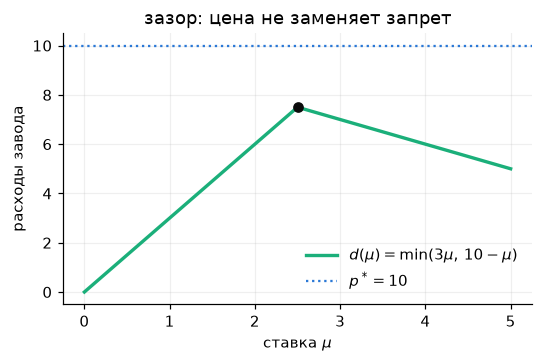

In [12]:
f_plant = {0.0: 0.0, 4.0: 10.0}                    # допустимое множество из двух точек
h_plant = lambda x: x - 3
mu_grid = np.linspace(0, 5, 501)
d_plant = np.array([min(fx - mu * h_plant(x) for x, fx in f_plant.items()) for mu in mu_grid])
i = np.argmax(d_plant)
p_star = min(fx for x, fx in f_plant.items() if h_plant(x) >= 0)
print(f"p* = {p_star}   d* = {d_plant[i]:.2f} при mu* = {mu_grid[i]:.2f}   зазор = {p_star - d_plant[i]:.2f}")
print("при mu* завод безразличен между 'стоять' и 'работать' — и в обоих случаях платит 7.5 < 10")

plt.figure(figsize=(5.5, 3.2))
plt.plot(mu_grid, d_plant, color=AQUA, lw=2.2, label="$d(\mu)=\min(3\mu,\,10-\mu)$")
plt.axhline(p_star, color=BLUE, ls=":", label="$p^*=10$")
plt.plot(mu_grid[i], d_plant[i], "o", color=INK)
plt.xlabel("ставка $\mu$"); plt.ylabel("расходы завода"); plt.legend(); plt.title("зазор: цена не заменяет запрет")
plt.show()

**Бесконечный зазор.** $\min -x_1x_2$ при $x_1+x_2\le1$, $x_1,x_2\ge0$ (раздел 6 конспекта). Цель невыпукла и не ограничена снизу на всём $\mathbb{R}^2$ — покажем, что $L(x,\mu)\to-\infty$ вдоль диагонали для *любого* фиксированного $\mu\ge0$, значит $d(\mu)\equiv-\infty$.

In [13]:
f_nc = lambda x: -x[0] * x[1]
res_nc = minimize(f_nc, x0=[0.4, 0.4], bounds=[(0, 1), (0, 1)],
                   constraints=[{"type": "ineq", "fun": lambda x: 1 - x[0] - x[1]}])
print("p* (численно) =", round(res_nc.fun, 4), " при x* =", res_nc.x.round(4), " (теория: -0.25 при (0.5, 0.5))")

mu = np.array([1.0, 0.5, 0.5])           # любой фиксированный допустимый mu
h_nc = lambda x: np.array([1 - x[0] - x[1], x[0], x[1]])
for t in (1, 10, 100, 1000, 10_000):
    x = np.array([t, t], float)
    print(f"  t={t:6d}: L(x,mu) = {f_nc(x) - mu @ h_nc(x):.1f}")
print("-> L уходит в -inf вдоль диагонали при ЛЮБОМ mu: d(mu) = -inf, зазор бесконечен")

p* (численно) = -0.25  при x* = [0.5 0.5]  (теория: -0.25 при (0.5, 0.5))
  t=     1: L(x,mu) = -1.0
  t=    10: L(x,mu) = -91.0
  t=   100: L(x,mu) = -9901.0
  t=  1000: L(x,mu) = -999001.0
  t= 10000: L(x,mu) = -99990001.0
-> L уходит в -inf вдоль диагонали при ЛЮБОМ mu: d(mu) = -inf, зазор бесконечен


**Скрытая выпуклость.** А вот задача «прямоугольник в круге» из ДЗ 2 — тоже невыпуклая (нелинейное равенство!) — зазора не имеет вовсе (упражнение 14.5 разбирает это подробно). Проверим численно: $\min -4x_1x_2$ при $x_1^2+x_2^2=1$, $x_1,x_2\ge0$.

In [14]:
f_circ = lambda x: -4 * x[0] * x[1]
res_circ = minimize(f_circ, x0=[0.9, 0.1], bounds=[(0, 1), (0, 1)],
                     constraints=[{"type": "eq", "fun": lambda x: x[0] ** 2 + x[1] ** 2 - 1}])
print("p* (численно) =", round(res_circ.fun, 6), " при x* =", res_circ.x.round(4))

# d(lambda) в явном виде (раздел 14.5): матрица [[lambda, -2], [-2, lambda]] >= 0  <=>  lambda >= 2
for lam in (1.5, 2.0, 2.5, 3.0):
    eig = np.linalg.eigvalsh(np.array([[lam, -2.0], [-2.0, lam]]))
    d_lam = -lam if eig.min() >= -1e-9 else -np.inf
    print(f"lambda={lam}: собственные числа = {eig.round(3)}, d(lambda) = {d_lam}")
print("\nd* = max_{lambda >= 2} (-lambda) = -2 = p* -- зазора нет, хотя задача невыпукла!")

p* (численно) = -2.0  при x* = [0.7071 0.7071]
lambda=1.5: собственные числа = [-0.5  3.5], d(lambda) = -inf
lambda=2.0: собственные числа = [0. 4.], d(lambda) = -2.0
lambda=2.5: собственные числа = [0.5 4.5], d(lambda) = -2.5
lambda=3.0: собственные числа = [1. 5.], d(lambda) = -3.0

d* = max_{lambda >= 2} (-lambda) = -2 = p* -- зазора нет, хотя задача невыпукла!


Разница объясняется структурой: у «прямоугольника» — ровно **одно** квадратичное равенство, и для такого частного случая (лемма С, S-lemma) двойственность всегда точна, несмотря на невыпуклость. У задачи с $-x_1x_2$ на многоугольнике невыпуклость «настоящая» — ограничений много и они линейны, спрятать провал цели за одним множителем не получается. Мораль: «невыпукло» — не значит «двойственность обязательно врёт», но и не значит «двойственность обязательно права»; проверять нужно каждый раз.

## Шпаргалка

| Вопрос | Как проверить | Инструмент |
|---|---|---|
| нижняя граница на $p^\ast$ без решения задачи? | взять любые $\lambda,\ \mu\ge0$, посчитать $d(\lambda,\mu)$ | всегда работает (слабая двойственность) |
| зазора нет? | задача выпукла (лекция 2, чек-лист) + условие Слейтера | для LP — всегда, если задача разрешима |
| теневые цены LP | `res.ineqlin.marginals` (со знаком) | `scipy.optimize.linprog` |
| множители QP | максимизировать $d(\mu)$ по $\mu\ge0$ или решить KKT | `minimize` на $-d(\mu)$ с `bounds=[(0,None),...]` |
| какое ограничение активно? | $\mu_i^\ast>0 \Leftrightarrow$ ограничение $i$ активно (при сильной двойственности) | комплементарная нежёсткость |

Три типичные ошибки:

1. **«Раз $d(\mu)\le p^\ast$, значит $d(\mu)$ близко к $p^\ast$».** Нет: слабая двойственность гарантирует только неравенство. Оценка хороша лишь при $\mu$, близком к $\mu^\ast$ — а без решения задачи узнать это заранее нельзя.
2. **Забыть про $\mu\ge0$.** Двойственная задача — это максимизация $d$ **на неотрицательном ортанте**, а не на всём пространстве; отрицательный $\mu$ не имеет смысла (штраф поменял бы направление).
3. **«Невыпуклая задача — двойственность бесполезна».** Не всегда: скрытая выпуклость отдельных структур (одно квадратичное ограничение — часть (d) выше) — реальное и полезное исключение.